In [1]:
import pandas as pd

df = pd.read_csv("Zoo.csv")

In [2]:
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


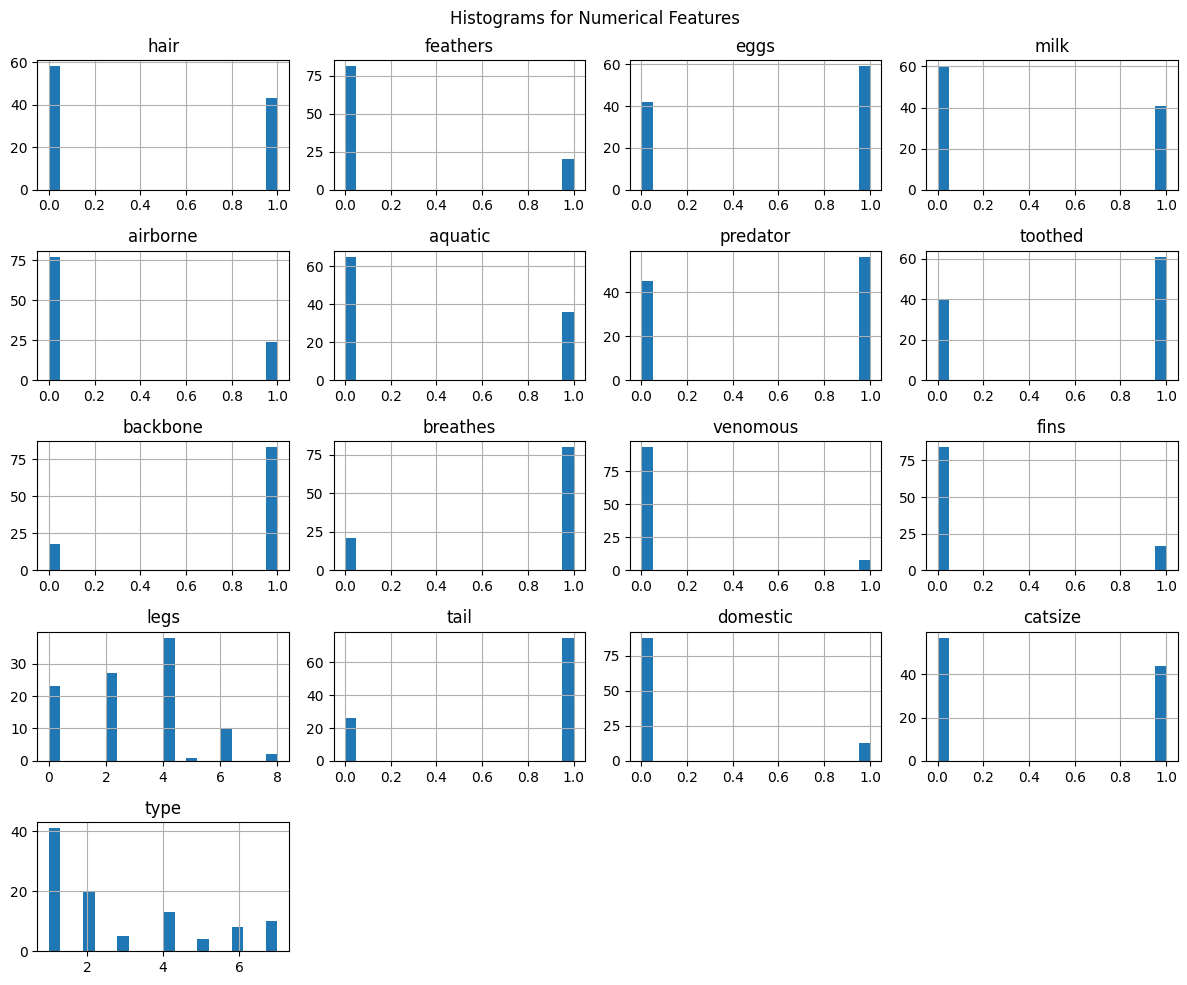

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for each numerical feature
df.drop(columns=['animal name'], axis=1).hist(figsize=(12, 10), bins=20)
plt.suptitle("Histograms for Numerical Features")
plt.tight_layout()
plt.show()

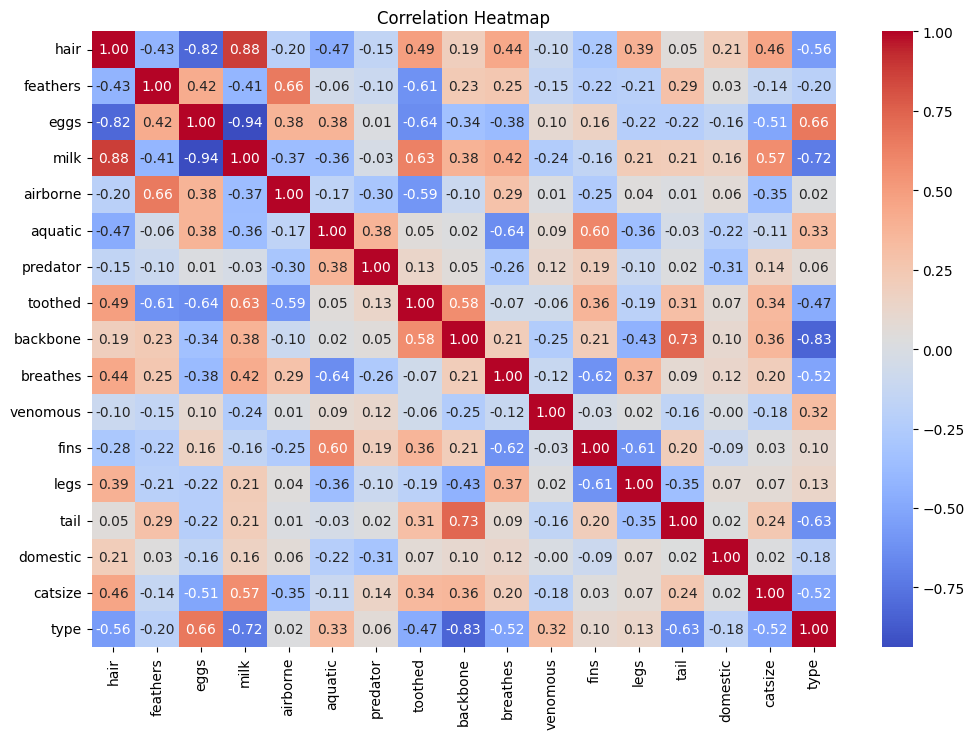

In [5]:
# Correlation matrix
corr = df.drop(columns=['animal name']).corr()

# Heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

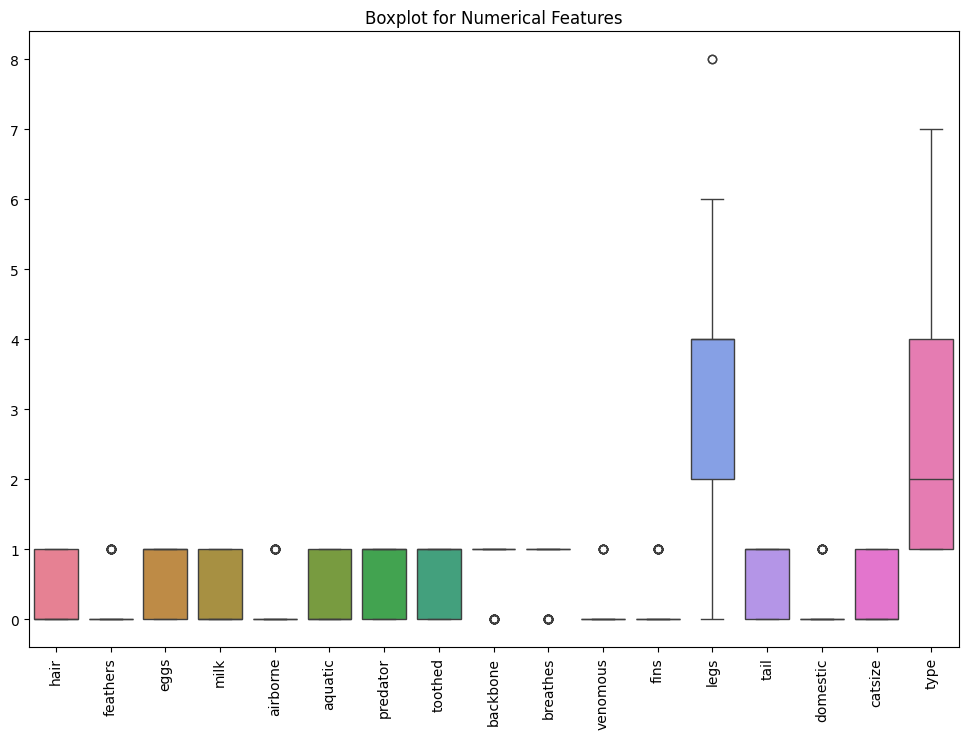

In [6]:
# Boxplot for outliers detection
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.drop(columns=['animal name']))
plt.title("Boxplot for Numerical Features")
plt.xticks(rotation=90)
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns=['animal name', 'type']))

# Convert back to DataFrame for readability
scaled_df = pd.DataFrame(scaled_features, columns=df.columns[1:-1])

In [8]:
from sklearn.model_selection import train_test_split

X = scaled_df
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Instantiate the model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9354838709677419
Classification Report:
              precision    recall  f1-score   support

           1       0.94      1.00      0.97        15
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         5
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.80      0.81      0.80        31
weighted avg       0.92      0.94      0.92        31



In [13]:
import numpy as np
print(np.unique(y_train))

[1 2 3 4 5 6 7]


In [14]:
y_train = y_train - 1
y_test = y_test - 1

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Example dataset: Replace with your actual dataset
# X = df.drop('target', axis=1)  # Your feature columns
# y = df['target']  # Your target column

# Label encode the target variable if it's categorical
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Calculate sample weights based on class distribution in the training set
sample_weights = compute_sample_weight('balanced', y_train)

# Initialize the XGBoost model without scale_pos_weight (for multi-class)
xgb_model = XGBClassifier(random_state=42)

# Train the model, passing the computed sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model with classification report (including precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Optional: Print confusion matrix to understand the predictions better
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Precision score with zero_division handling
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
print(f"Macro Precision Score: {precision}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         2
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21

Confusion Matrix:
[[12  0  0  0  0  0]
 [ 0  2  0  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  1]]
Macro Precision Score: 0.7777777777777777


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Example dataset (replace with your actual dataset)
# X = df.drop('target', axis=1)  # Your feature columns
# y = df['target']  # Your target column

# Label encode the target variable if it's categorical
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train-test split (optional if you need to separate the data for validation)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Stratified KFold cross-validation
stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=stratified_kfold, scoring='accuracy')

# Print cross-validation results
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean()}")

# Train the model on the full training set
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))  # Added zero_division=0 to suppress warning

# Optional: Accuracy score on test set
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {accuracy}")

Cross-validation accuracy scores: [1.         0.92592593 0.92307692]
Mean accuracy: 0.949667616334283
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         2
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21

Accuracy on test set: 0.9523809523809523


Length of y_test: 21
Length of y_pred_xgb: 21


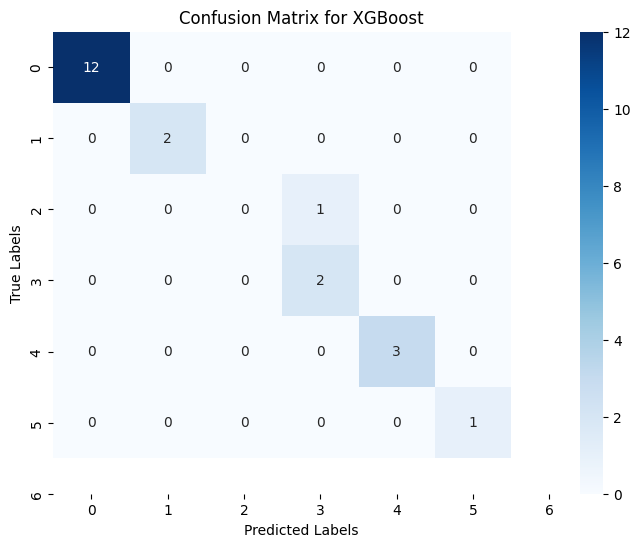

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming X and y are your feature and target variables
# X = df.drop('target', axis=1)  # Features
# y = df['target']  # Target

# Re-label the classes to start from 0
encoder = LabelEncoder()
y = encoder.fit_transform(y)  # This will automatically adjust labels to start from 0

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Check if y_test and y_pred_xgb have the same length
print(f"Length of y_test: {len(y_test)}")
print(f"Length of y_pred_xgb: {len(y_pred_xgb)}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

# Split the data into features (X) and target variable (y)
X = df.drop(columns=['animal name', 'type'])  # Drop 'animal name' and 'type' columns
y = df['type']  # Target variable

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the train and test sets
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 80
Test set size: 21


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Precision, Recall, F1-Score with handling of zero division
precision = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

# Print evaluation metrics
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Precision: 0.015873015873015872
Recall: 0.047619047619047616
F1-Score: 0.023809523809523808


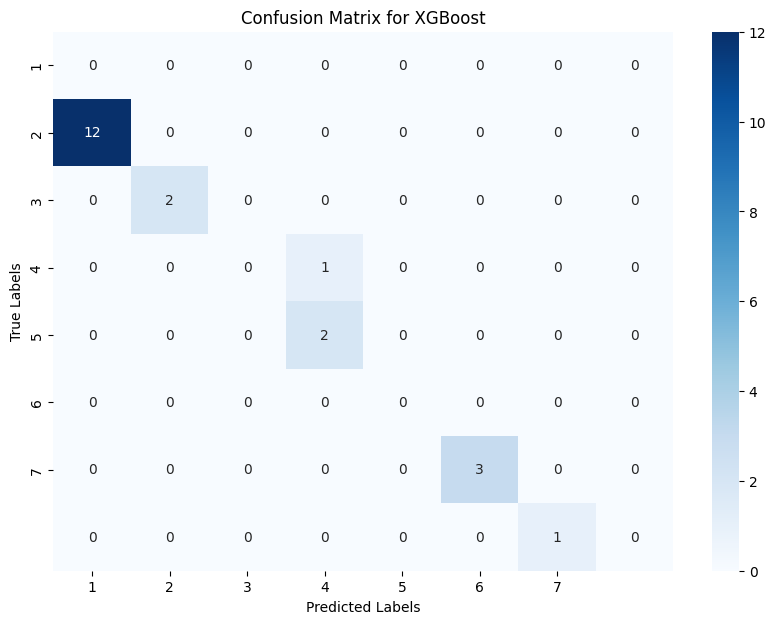

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for XGBoost')
plt.show()

Precision: 0.9206349206349207
Recall: 0.9523809523809523
F1-Score: 0.9333333333333333


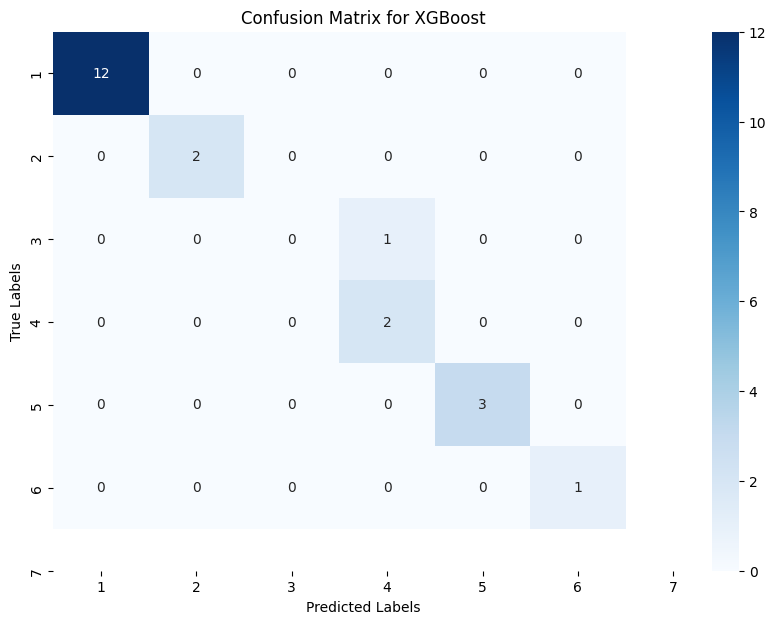

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Example: Loading your dataset (replace this with your actual dataset)
# data = pd.read_csv("your_dataset.csv")

# For demonstration purposes, let’s assume the data looks something like this:
# X = data.drop('target', axis=1)
# y = data['target']

# Label encoding for y if it's categorical
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)  # Encoding target variable if needed

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)

# Fit the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate precision, recall, and F1 scores with zero_division handling
precision = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

# Print evaluation metrics
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for XGBoost')
plt.show()

# Handling class imbalance by adjusting scale_pos_weight if needed
# Example of how you can try setting this parameter for imbalanced classes
# xgb_model = xgb.XGBClassifier(scale_pos_weight=class_imbalance_factor)

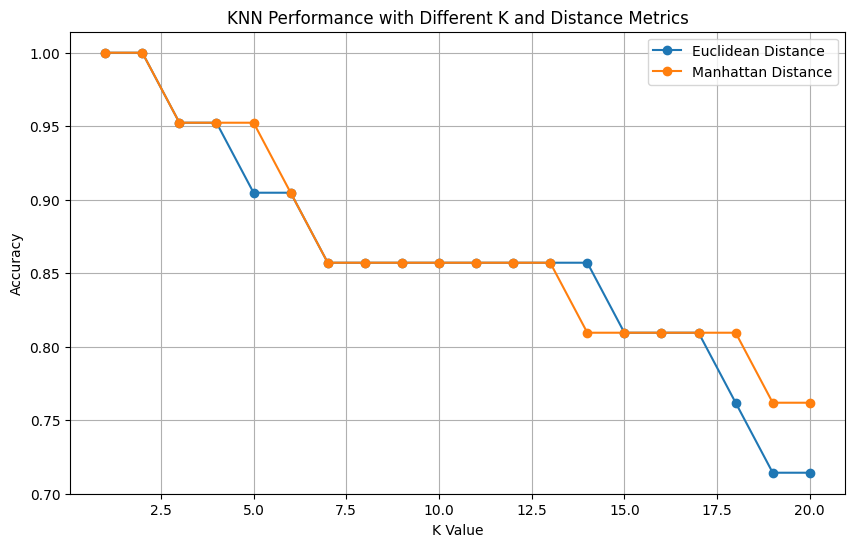

Best K for Euclidean distance: 1, Accuracy: 1.0
Best K for Manhattan distance: 1, Accuracy: 1.0


In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# List of different K values to test
k_values = range(1, 21)

# Empty lists to store accuracy for each K
accuracy_euclidean = []
accuracy_manhattan = []

# Loop through each K value and evaluate the model with both distance metrics
for k in k_values:
    # Euclidean distance
    knn_euclidean = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_euclidean.fit(X_train, y_train)
    y_pred_euclidean = knn_euclidean.predict(X_test)
    accuracy_euclidean.append(accuracy_score(y_test, y_pred_euclidean))
    
    # Manhattan distance
    knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_manhattan.fit(X_train, y_train)
    y_pred_manhattan = knn_manhattan.predict(X_test)
    accuracy_manhattan.append(accuracy_score(y_test, y_pred_manhattan))

# Plot the results to compare accuracy with different K values and distance metrics
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_euclidean, label='Euclidean Distance', marker='o')
plt.plot(k_values, accuracy_manhattan, label='Manhattan Distance', marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Performance with Different K and Distance Metrics')
plt.legend()
plt.grid(True)
plt.show()

# Print the best K values and their corresponding accuracies
best_k_euclidean = k_values[accuracy_euclidean.index(max(accuracy_euclidean))]
best_k_manhattan = k_values[accuracy_manhattan.index(max(accuracy_manhattan))]
print(f"Best K for Euclidean distance: {best_k_euclidean}, Accuracy: {max(accuracy_euclidean)}")
print(f"Best K for Manhattan distance: {best_k_manhattan}, Accuracy: {max(accuracy_manhattan)}")

Precision: 1.0
Recall: 1.0
F1-Score: 1.0


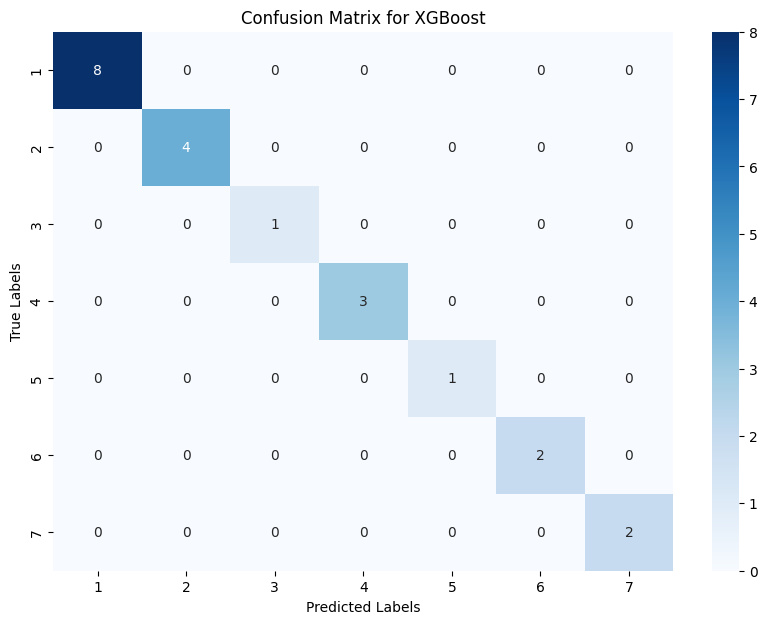

In [35]:
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Suppress warnings (optional)
warnings.filterwarnings("ignore", category=UserWarning)

# Example: Loading your dataset (replace this with your actual dataset)
# data = pd.read_csv("your_dataset.csv")

# For demonstration purposes, let’s assume the data looks something like this:
# X = data.drop('target', axis=1)
# y = data['target']

# Label encoding for y if it's categorical
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)  # Encoding target variable if needed

# Split the data into train and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Initialize the XGBoost model with class weights if needed
xgb_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=1)  # Adjust scale_pos_weight if necessary

# Fit the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate precision, recall, and F1 scores with zero_division handling
precision = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

# Print evaluation metrics
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for XGBoost')
plt.show()

# Handling class imbalance by adjusting scale_pos_weight if needed
# Example of how you can try setting this parameter for imbalanced classes
# xgb_model = xgb.XGBClassifier(scale_pos_weight=class_imbalance_factor)

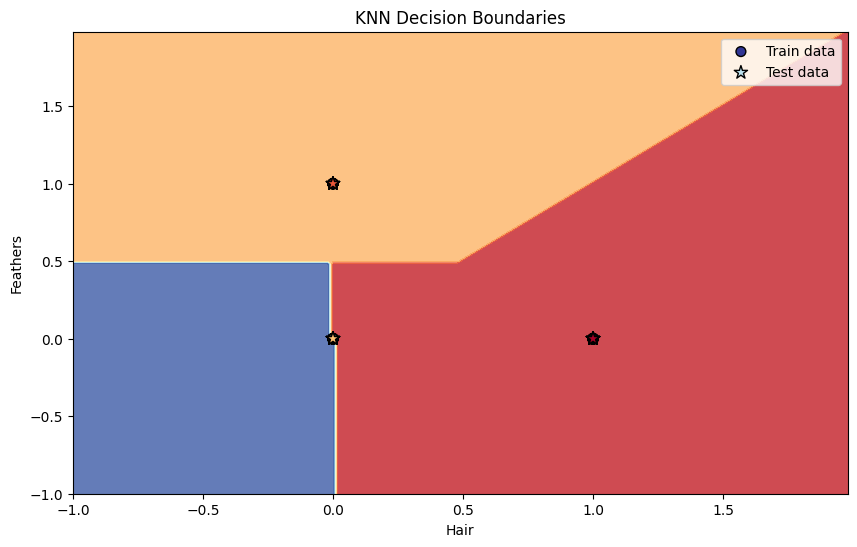

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Select the first two features for visualization (you can choose other features)
X_train_2d = X_train[['hair', 'feathers']]  # Example: using 'hair' and 'feathers' columns
X_test_2d = X_test[['hair', 'feathers']]  # Same for the test set

# Train the KNN model on these two features
knn_model_2d = KNeighborsClassifier(n_neighbors=5)
knn_model_2d.fit(X_train_2d, y_train)

# Create a mesh grid for plotting decision boundaries
h = 0.02  # Step size in the mesh grid
x_min, x_max = X_train_2d['hair'].min() - 1, X_train_2d['hair'].max() + 1
y_min, y_max = X_train_2d['feathers'].min() - 1, X_train_2d['feathers'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict the class for each point in the mesh grid
Z = knn_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the training points
plt.scatter(X_train_2d['hair'], X_train_2d['feathers'], c=y_train, s=50, edgecolor='k', cmap=plt.cm.RdYlBu, label='Train data')
# Plot the test points
plt.scatter(X_test_2d['hair'], X_test_2d['feathers'], c=y_test, s=100, marker='*', edgecolor='k', cmap=plt.cm.RdYlBu, label='Test data')

plt.title('KNN Decision Boundaries')
plt.xlabel('Hair')
plt.ylabel('Feathers')
plt.legend()
plt.show()